In [30]:
import pandas as pd

df = pd.read_csv("resultados_experimentacion.csv")
df

,problema,n,k,algoritmo,status,synthesis_time_ms,max_memory_mb,expanded_states,used_states,expanded_transitions,used_transitions,heuristic_time_ms
0,AT,1,1,MonolithicController,OK,3.0,9.56,6.0,6.0,8.0,8.0,0.0
1,AT,1,1,DirectedController,OK,45.0,15.41,6.0,6.0,8.0,8.0,0.0
2,AT,1,1,PORController,OK,30.0,15.41,6.0,6.0,8.0,8.0,0.0
3,AT,1,1,PORGeneralizedController,OK,34.0,10.94,6.0,6.0,8.0,8.0,0.0
4,AT,1,2,MonolithicController,OK,2.0,9.55,7.0,7.0,10.0,9.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3370,BW,15,11,PORControllerGivenIsomorphisms,TO,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3371,BW,15,12,PORControllerGivenIsomorphisms,TO,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3372,BW,15,13,PORControllerGivenIsomorphisms,TO,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3373,BW,15,14,PORControllerGivenIsomorphisms,TO,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
k = 6  # cambiá este valor

df_k = df[df["k"] == k]
tabla = df_k.pivot_table(index="n", columns="algoritmo", values="max_memory_mb")
tabla

algoritmo,DirectedController,MonolithicController,PORController,PORControllerGivenIsomorphisms,PORGeneralizedController
n,,,,,
1,15.906667,11.383333,17.753333,7.140000,13.093333
2,193.510000,280.990000,99.923333,9.686667,211.673333
3,18.855000,39.720000,1113.810000,163.160000,29.150000
4,59.850000,298.620000,96.630000,1073.360000,106.915000
5,144.965000,1413.120000,823.095000,490.475000,1344.545000
6,1145.860000,NaN,NaN,670.130000,2990.080000
7,84.780000,NaN,NaN,0.000000,NaN
8,162.630000,NaN,NaN,0.000000,NaN
9,261.450000,NaN,NaN,95.320000,NaN


In [32]:
casos_resueltos = (
    df[df["status"] == "OK"]
    .groupby("algoritmo")
    .size()
    .rename("casos_resueltos")
    .sort_values(ascending=False)
)
total = pd.Series({"TOTAL": casos_resueltos.sum()}, name="casos_resueltos")
pd.concat([casos_resueltos, total])

DirectedController                 326
PORControllerGivenIsomorphisms     306
PORGeneralizedController           198
PORController                      193
MonolithicController               169
TOTAL                             1192
Name: casos_resueltos, dtype: int64

In [33]:
ok = df[df["status"] == "OK"]

max_n = (
    ok.sort_values(["algoritmo", "n", "k"], ascending=[True, False, False])
    .groupby("algoritmo")
    .first()[["n", "k"]]
    .rename(columns={"n": "max_n", "k": "k_en_max_n"})
)

max_k = (
    ok.sort_values(["algoritmo", "k", "n"], ascending=[True, False, False])
    .groupby("algoritmo")
    .first()[["k", "n"]]
    .rename(columns={"k": "max_k", "n": "n_en_max_k"})
)

max_n.join(max_k)

,max_n,k_en_max_n,max_k,n_en_max_k
algoritmo,,,,
DirectedController,15,3,15,13
MonolithicController,9,1,15,4
PORController,11,1,15,4
PORControllerGivenIsomorphisms,15,7,15,5
PORGeneralizedController,11,1,15,4


In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_algoritmo(algoritmo, problema):
    datos = df[(df["algoritmo"] == algoritmo) & (df["problema"] == problema)].copy()
    resueltos = datos[datos["status"] == "OK"][["n", "k"]]
    no_resueltos = datos[datos["status"] != "OK"][["n", "k"]]

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(resueltos["n"], resueltos["k"], color="green", marker="o", s=120, label="Resuelto", zorder=3)
    ax.scatter(no_resueltos["n"], no_resueltos["k"], color="red", marker="x", s=120, linewidths=2, label="No resuelto", zorder=3)

    all_n = sorted(datos["n"].unique())
    all_k = sorted(datos["k"].unique())
    ax.set_xticks(all_n)
    ax.set_yticks(all_k)
    ax.set_xlabel("n")
    ax.set_ylabel("k")
    ax.set_title(f"{algoritmo} — {problema}")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0.)
    ax.grid(True, linestyle="--", alpha=0.5)
    fig.subplots_adjust(right=0.75)
    plt.show()

def plot_problema(problema):
    for algoritmo in sorted(df["algoritmo"].unique()):
        plot_algoritmo(algoritmo, problema)

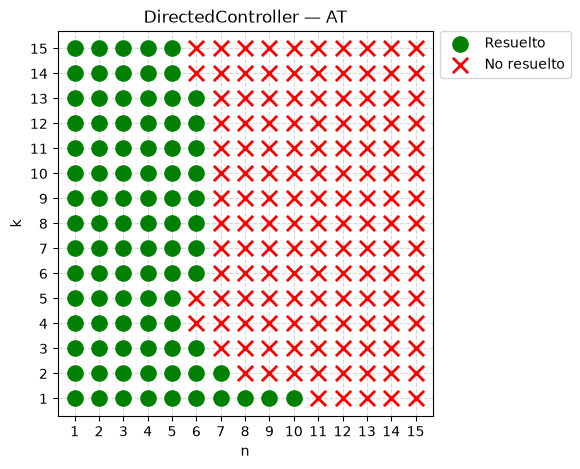

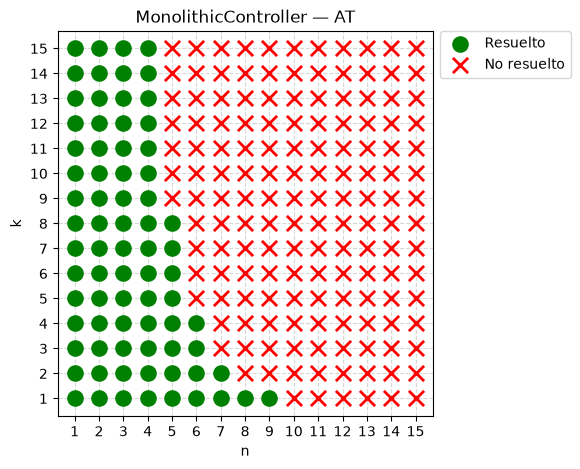

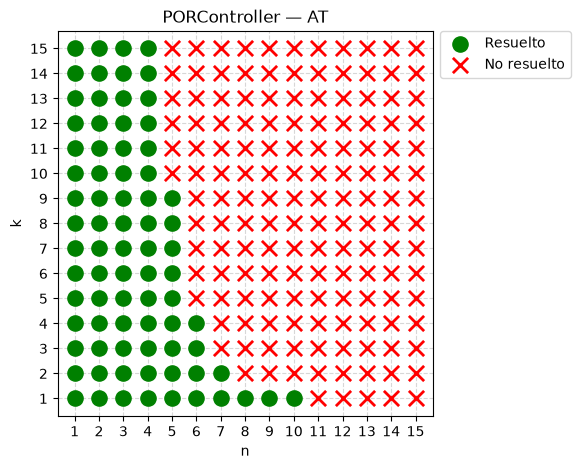

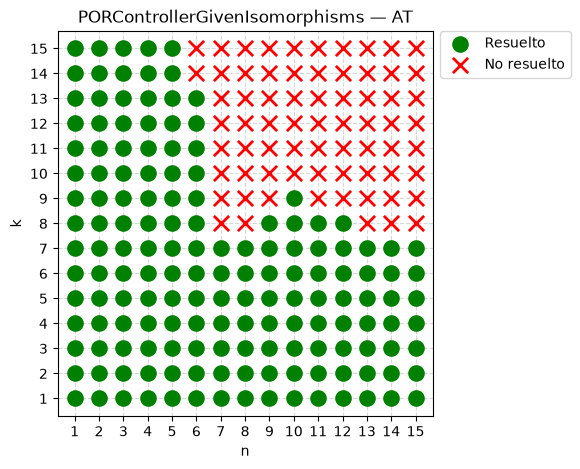

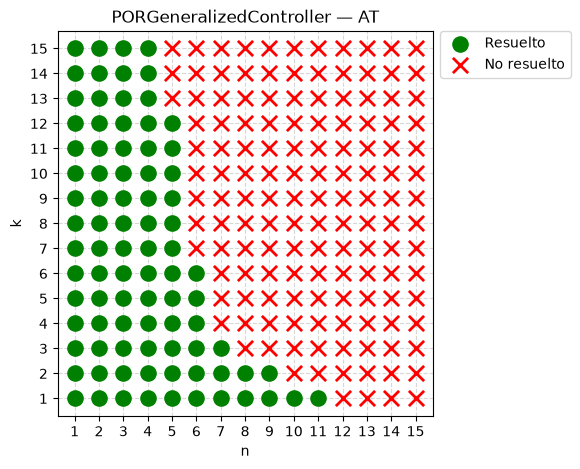

In [35]:
plot_problema("AT")

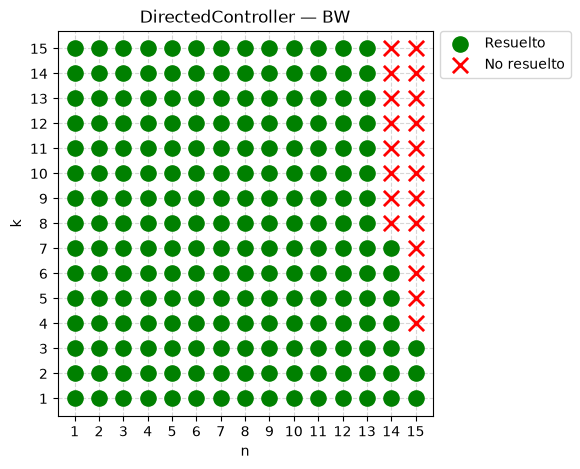

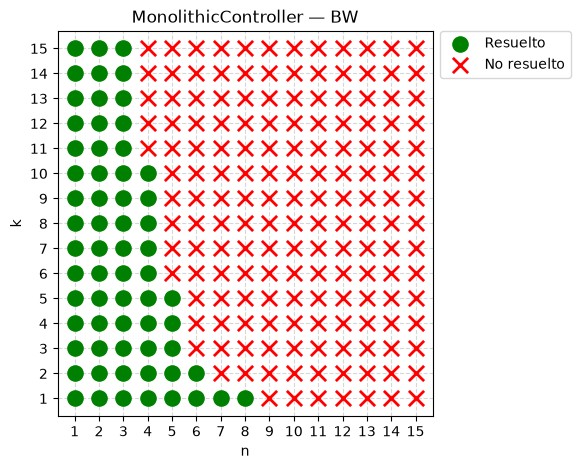

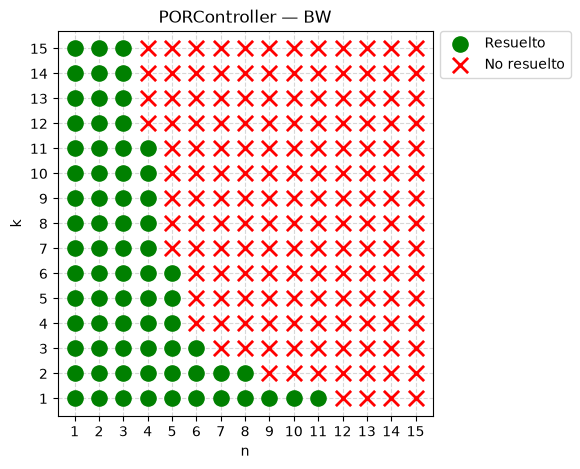

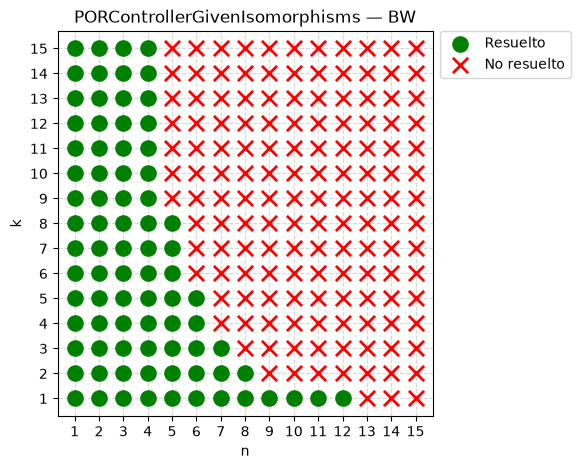

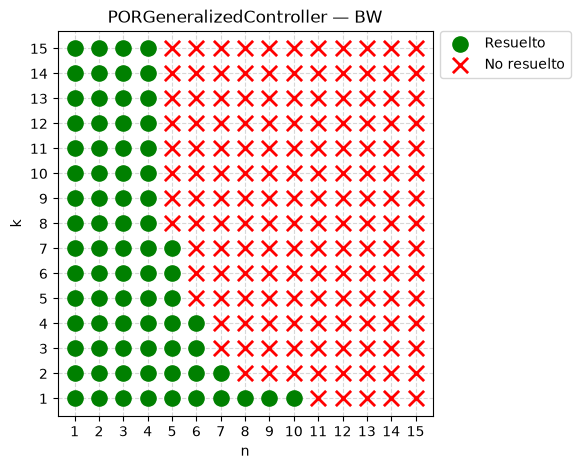

In [36]:
plot_problema("BW")

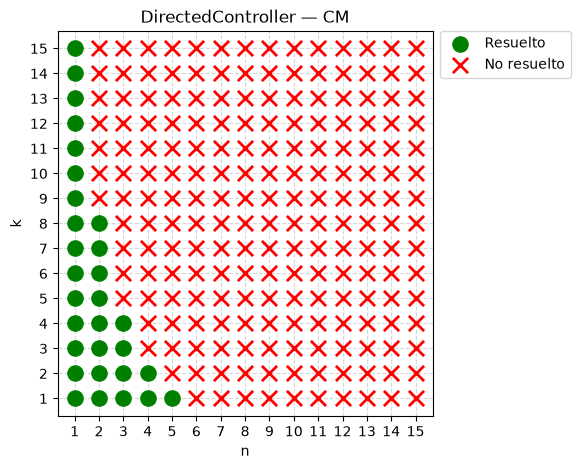

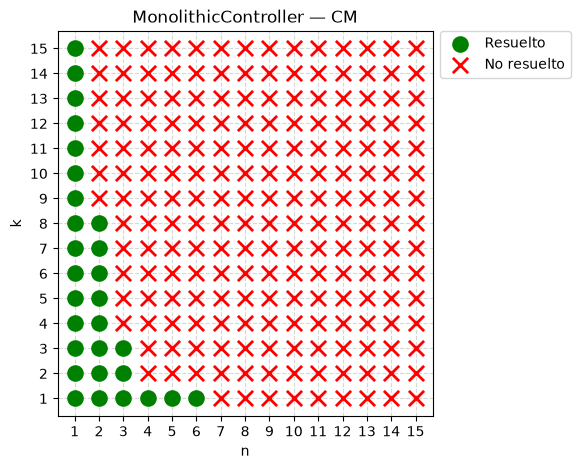

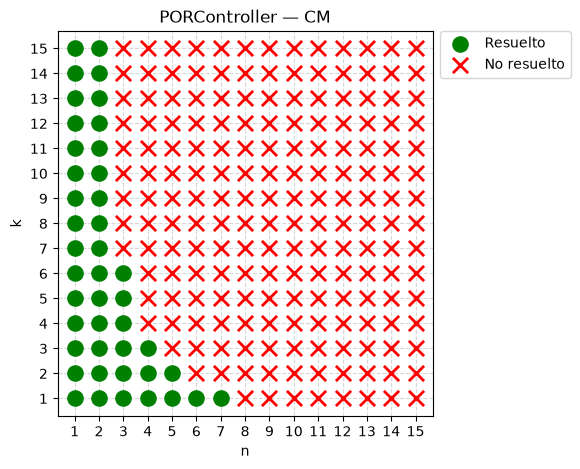

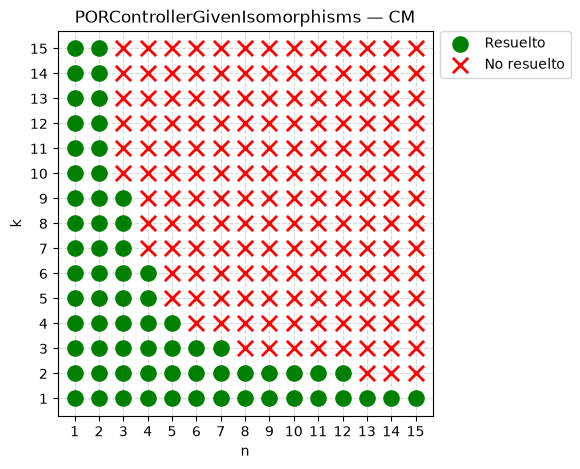

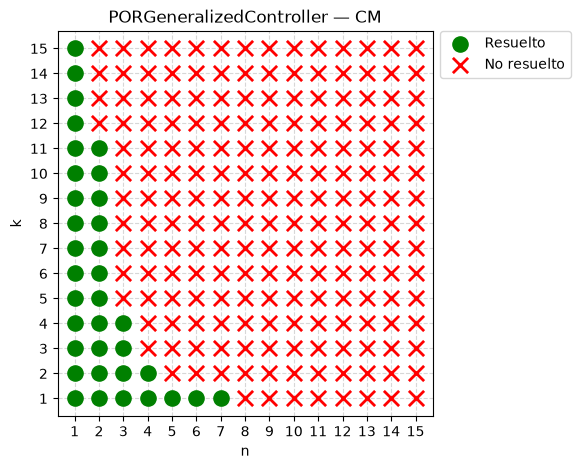

In [37]:
plot_problema("CM")

In [38]:
df[df["status"] == "OK"].groupby("algoritmo")["expanded_states"].max().rename("max_expanded_states").sort_values(ascending=False)

algoritmo
PORController                     1516429.0
PORControllerGivenIsomorphisms    1281852.0
PORGeneralizedController           628354.0
MonolithicController               437131.0
DirectedController                 163839.0
Name: max_expanded_states, dtype: float64

In [39]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm

ALGORITHMS = ["MonolithicController", "DirectedController", "PORController", "PORGeneralizedController"]

# Rampa secuencial (azul, claro -> oscuro) para codificar magnitud de memoria
BLUE_RAMP = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec",
             "#5598e7", "#3987e5", "#2a78d6", "#256abf", "#1c5cab",
             "#184f95", "#104281", "#0d366b"]
CMAP_MEMORIA = LinearSegmentedColormap.from_list("memoria_seq", BLUE_RAMP)
CMAP_MEMORIA.set_bad("#e0e0dc")  # gris = sin dato (OM/TO)

def plot_memoria_heatmap(problema="AT"):
    datos = df[df["problema"] == problema]
    todos_n = sorted(datos["n"].unique())
    todos_k = sorted(datos["k"].unique())

    # Misma escala de color en los 4 paneles -> permite comparar entre algoritmos
    norm = LogNorm(vmin=datos["max_memory_mb"].min(), vmax=datos["max_memory_mb"].max())

    fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
    for ax, algo in zip(axes.flat, ALGORITHMS):
        tabla = (
            datos[datos["algoritmo"] == algo]
            .pivot_table(index="k", columns="n", values="max_memory_mb")
            .reindex(index=todos_k, columns=todos_n)
        )
        im = ax.imshow(tabla.values, origin="lower", cmap=CMAP_MEMORIA, norm=norm, aspect="auto")
        ax.set_xticks(range(len(todos_n)))
        ax.set_xticklabels(todos_n)
        ax.set_yticks(range(len(todos_k)))
        ax.set_yticklabels(todos_k)
        ax.set_xlabel("n")
        ax.set_ylabel("k")
        ax.set_title(algo)

    fig.colorbar(im, ax=axes, label="Memoria máxima usada (MB, escala log)", shrink=0.8)
    fig.suptitle(f"Uso de memoria en función de (n, k) — {problema}\n(gris = no resuelto: OOM o timeout)", y=0.99)
    plt.show()


In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, LogNorm

# Orden y nombres de las configuraciones, iguales a los del capítulo de experimentación
ALGORITMOS_HEATMAP = [
    ("MonolithicController", "Monolítico"),
    ("DirectedController", "OTF"),
    ("PORController", "Sim. Braier"),
    ("PORGeneralizedController", "Sim. Gen."),
    ("PORControllerGivenIsomorphisms", "Iso. dados"),
]

TIMEOUT_MS = 30 * 60 * 1000

# Qué se grafica en cada métrica: columna, escala (fija para todos los paneles) y marcas de la barra de color
METRICAS = {
    "tiempo": {
        "columna": "synthesis_time_ms",
        "etiqueta": "Tiempo de síntesis (escala log)",
        "vmin": 1,
        "vmax": TIMEOUT_MS,
        "ticks": [1, 10, 100, 1_000, 10_000, 100_000, TIMEOUT_MS],
        "tick_labels": ["1 ms", "10 ms", "100 ms", "1 s", "10 s", "100 s", "30 min"],
    },
    "memoria": {
        "columna": "max_memory_mb",
        "etiqueta": "Memoria máxima usada (escala log)",
        "vmin": 5,
        "vmax": 4_000,
        "ticks": [10, 100, 1_000, 4_000],
        "tick_labels": ["10 MB", "100 MB", "1 GB", "4 GB"],
    },
}

# Rampa secuencial (azul, claro -> oscuro) para la magnitud; blanco = no resuelto (OM o TO)
CMAP_HEATMAP = LinearSegmentedColormap.from_list("heatmap_seq", BLUE_RAMP)
CMAP_HEATMAP.set_bad("white")

# Segunda rampa (naranja, claro -> oscuro) para las instancias de AT sin solución (n > k)
ORANGE_RAMP = ["#fce4d6", "#f8c3a5", "#f29f74", "#eb6834", "#c94d1c", "#9c3812", "#6e270c"]
CMAP_SIN_SOLUCION = LinearSegmentedColormap.from_list("sin_solucion_seq", ORANGE_RAMP)
CMAP_SIN_SOLUCION.set_bad((0, 0, 0, 0))  # transparente: debajo queda el panel azul

COLOR_SIN_DATO = "#9a9a96"   # resuelto, pero la memoria registrada es 0 MB (dato inválido)
COLOR_GRILLA = "#e0e0dc"


def _panel(ax, datos, algo, metrica, todos_n, todos_k, norm, separar_solucion=False):
    cfg = METRICAS[metrica]
    col = cfg["columna"]
    resueltos = datos[(datos["algoritmo"] == algo) & (datos["status"] == "OK")]

    tabla = (
        resueltos.pivot_table(index="k", columns="n", values=col)
        .reindex(index=todos_k, columns=todos_n)
    )
    valores = tabla.values.astype(float)
    sin_dato = np.zeros_like(valores, dtype=bool)
    if metrica == "memoria":
        # MTSA a veces reporta 0 MB en instancias resueltas: no es un valor real, lo mostramos aparte
        sin_dato = valores == 0
        valores[sin_dato] = np.nan
    else:
        valores = np.clip(valores, cfg["vmin"], None)  # los 0 ms no entran en escala log

    ims = []
    if separar_solucion:
        # AT: con solución (n <= k) en azul, sin solución (n > k) en naranja
        N, K = np.meshgrid(todos_n, todos_k)
        con_solucion = N <= K
        ims.append(ax.imshow(np.where(con_solucion, valores, np.nan), origin="lower",
                             cmap=CMAP_HEATMAP, norm=norm, aspect="equal"))
        ims.append(ax.imshow(np.where(~con_solucion, valores, np.nan), origin="lower",
                             cmap=CMAP_SIN_SOLUCION, norm=norm, aspect="equal"))
    else:
        ims.append(ax.imshow(valores, origin="lower", cmap=CMAP_HEATMAP, norm=norm, aspect="equal"))
    ax.imshow(np.where(sin_dato, 1, np.nan), origin="lower", cmap=ListedColormap([COLOR_SIN_DATO]), aspect="equal")

    # Grilla fina entre celdas para que se distingan las no resueltas (blancas)
    ax.set_xticks(np.arange(-0.5, len(todos_n)), minor=True)
    ax.set_yticks(np.arange(-0.5, len(todos_k)), minor=True)
    ax.grid(which="minor", color=COLOR_GRILLA, linewidth=0.5)
    ax.tick_params(which="minor", length=0)
    ax.set_xticks(range(len(todos_n)))
    ax.set_xticklabels(todos_n, fontsize=7)
    ax.set_yticks(range(len(todos_k)))
    ax.set_yticklabels(todos_k, fontsize=7)
    ax.set_xlabel("n")
    ax.set_ylabel("k")

    if separar_solucion:
        # Escalón sobre la diagonal n = k: separa las celdas con solución (arriba) de las sin solución (abajo)
        xs, ys = [-0.5], [-0.5]
        for i in range(len(todos_n)):
            xs += [i + 0.5, i + 0.5]
            ys += [i - 0.5, i + 0.5]
        ax.plot(xs, ys, color="#3a3a38", linewidth=1)
        ax.set_xlim(-0.5, len(todos_n) - 0.5)
        ax.set_ylim(-0.5, len(todos_k) - 0.5)
        con = int((resueltos["n"] <= resueltos["k"]).sum())
        sin = len(resueltos) - con
        titulo = f"con solución {con}/120 · sin solución {sin}/105"
    else:
        titulo = f"{len(resueltos)}/{len(todos_n) * len(todos_k)} resueltas"
    return ims, titulo


def _leyenda(fig, metrica):
    handles = [mpatches.Patch(facecolor="white", edgecolor=COLOR_GRILLA, label="No resuelto (OM o TO)")]
    if metrica == "memoria":
        handles.append(mpatches.Patch(facecolor=COLOR_SIN_DATO, label="Resuelto, memoria registrada = 0 MB"))
    fig.legend(handles=handles, loc="outside lower center", ncol=len(handles), frameon=False)


def _barras_color(fig, axes, ims, metrica):
    cfg = METRICAS[metrica]
    etiquetas = [cfg["etiqueta"]] if len(ims) == 1 else [
        "Con solución (n ≤ k)",
        "Sin solución (n > k)",
    ]
    # constrained layout apila cada barra nueva más cerca de los paneles: las agregamos en orden inverso
    for im, etiqueta in reversed(list(zip(ims, etiquetas))):
        cbar = fig.colorbar(im, ax=axes, shrink=0.7, pad=0.01)
        cbar.set_label(etiqueta)
        cbar.set_ticks(cfg["ticks"])
        cbar.set_ticklabels(cfg["tick_labels"])


def plot_heatmap(problema="AT", metrica="tiempo"):
    """Heatmap de `metrica` ("tiempo" o "memoria") por instancia (n, k), un panel por algoritmo.

    En AT las instancias con solución (n <= k) se pintan en azul y las sin solución (n > k) en naranja.
    """
    cfg = METRICAS[metrica]
    datos = df[df["problema"] == problema]
    todos_n = sorted(df["n"].unique())
    todos_k = sorted(df["k"].unique())
    norm = LogNorm(vmin=cfg["vmin"], vmax=cfg["vmax"])
    separar = problema == "AT"

    fig, axes = plt.subplots(2, 3, figsize=(13, 8.5), sharex=True, sharey=True, layout="constrained")
    for ax, (algo, nombre) in zip(axes.flat, ALGORITMOS_HEATMAP):
        ims, titulo = _panel(ax, datos, algo, metrica, todos_n, todos_k, norm, separar)
        ax.set_title(f"{nombre}\n{titulo}", fontsize=10)
    axes.flat[-1].set_visible(False)

    _barras_color(fig, axes, ims, metrica)
    _leyenda(fig, metrica)
    fig.suptitle(f"{cfg['etiqueta'].split(' (')[0]} en función de (n, k) — {problema}")
    plt.show()

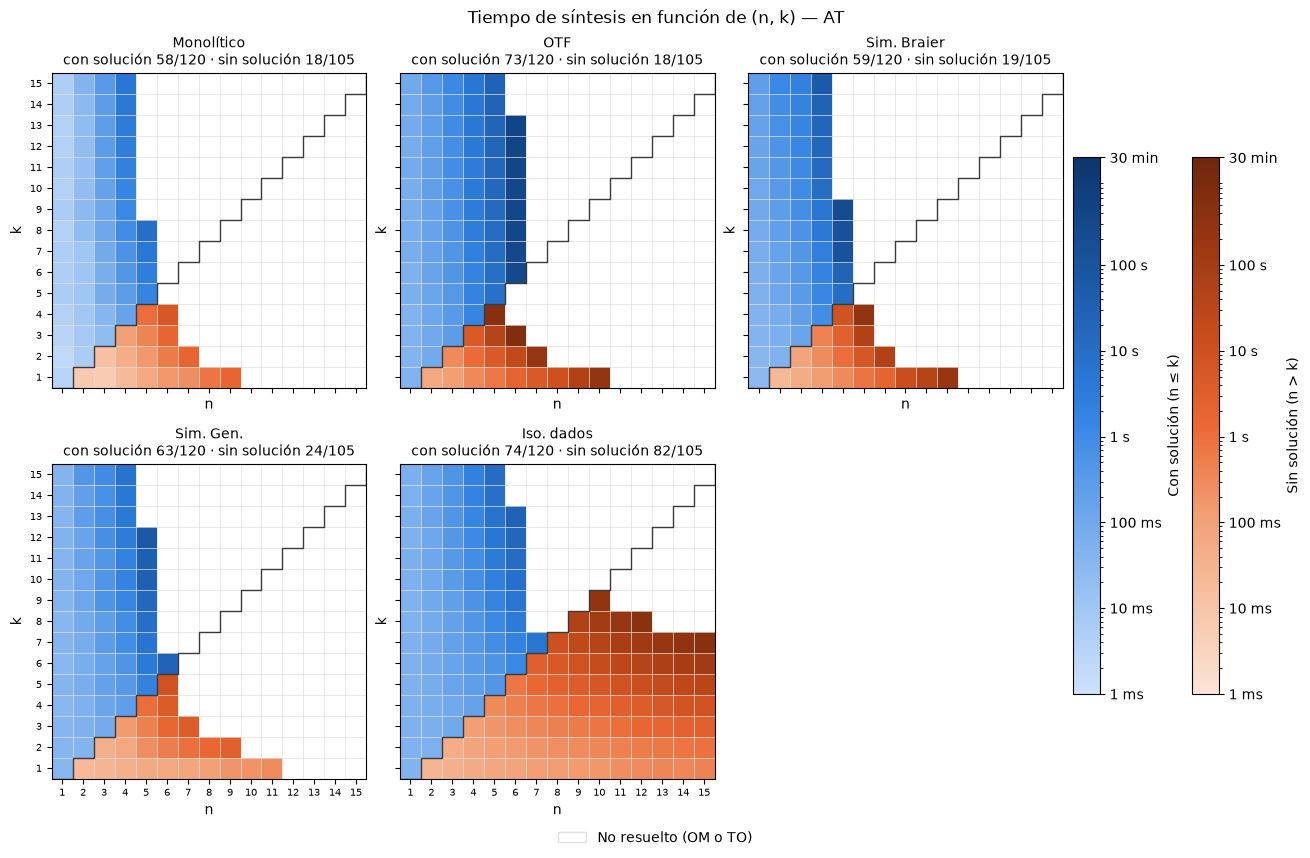

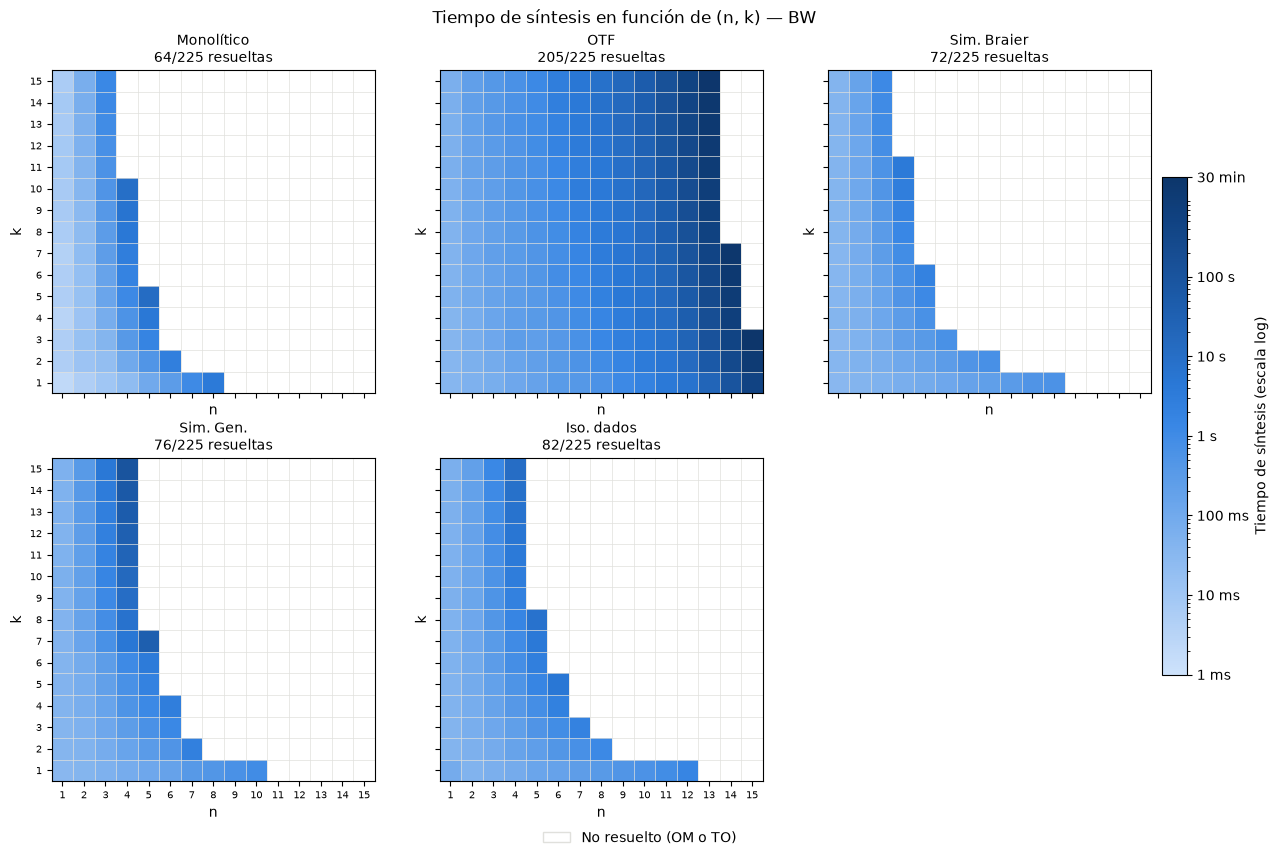

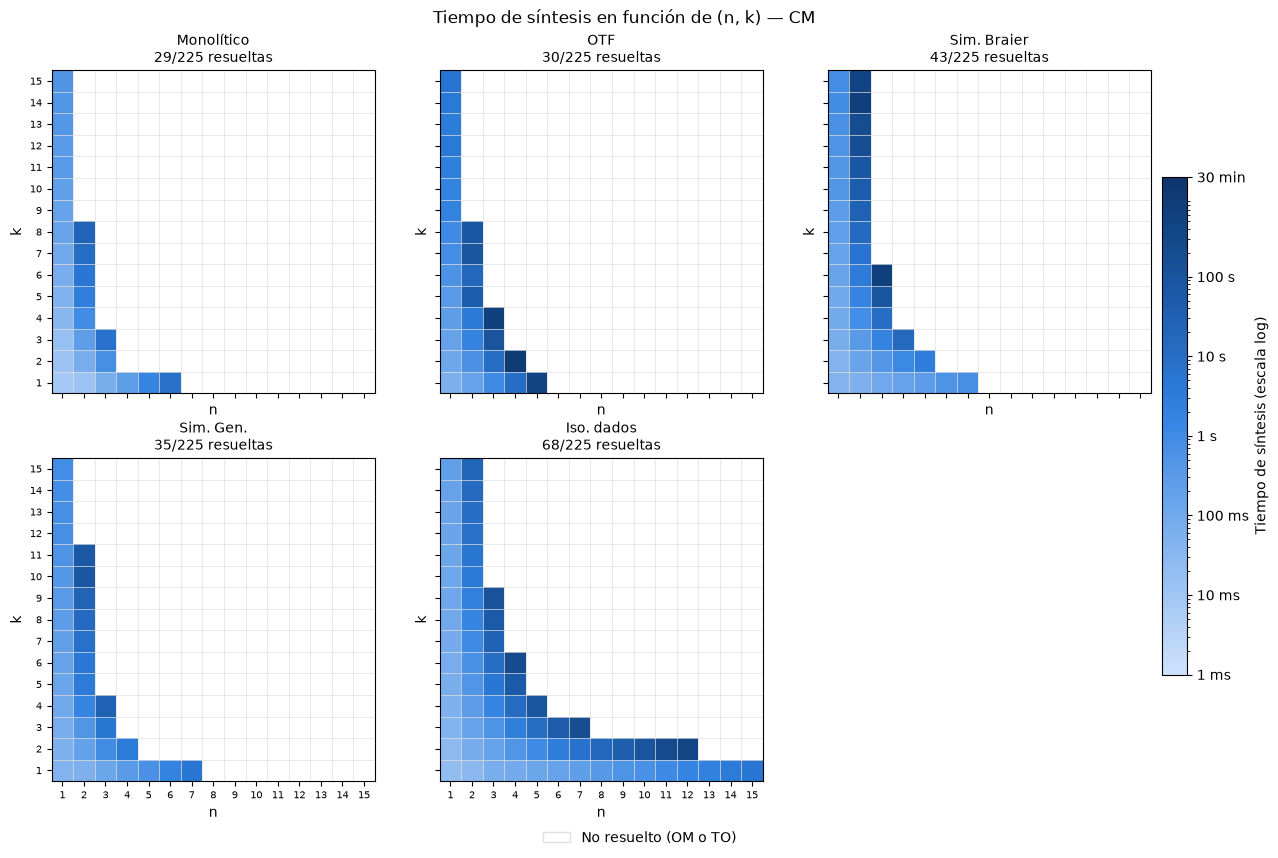

In [41]:
for problema in ["AT", "BW", "CM"]:
    plot_heatmap(problema, "tiempo")

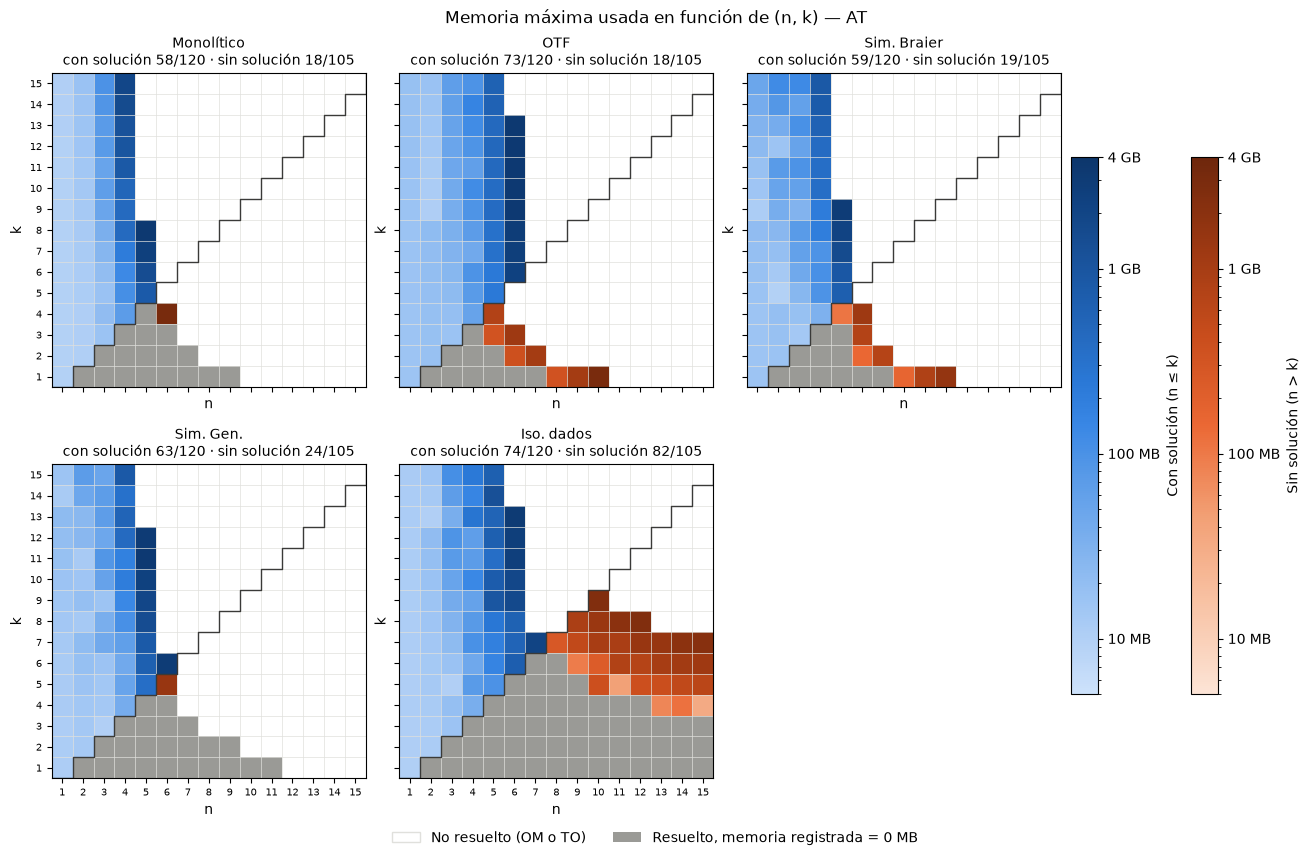

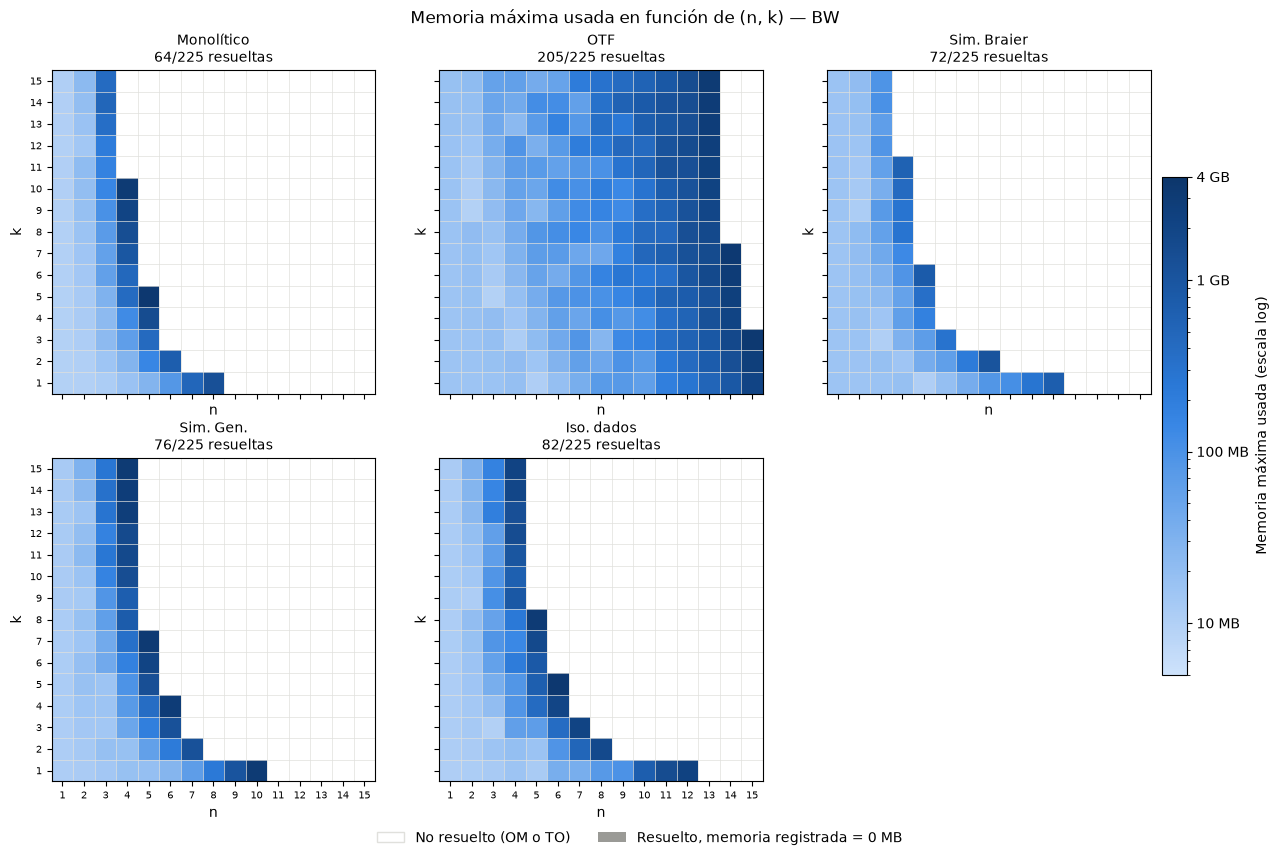

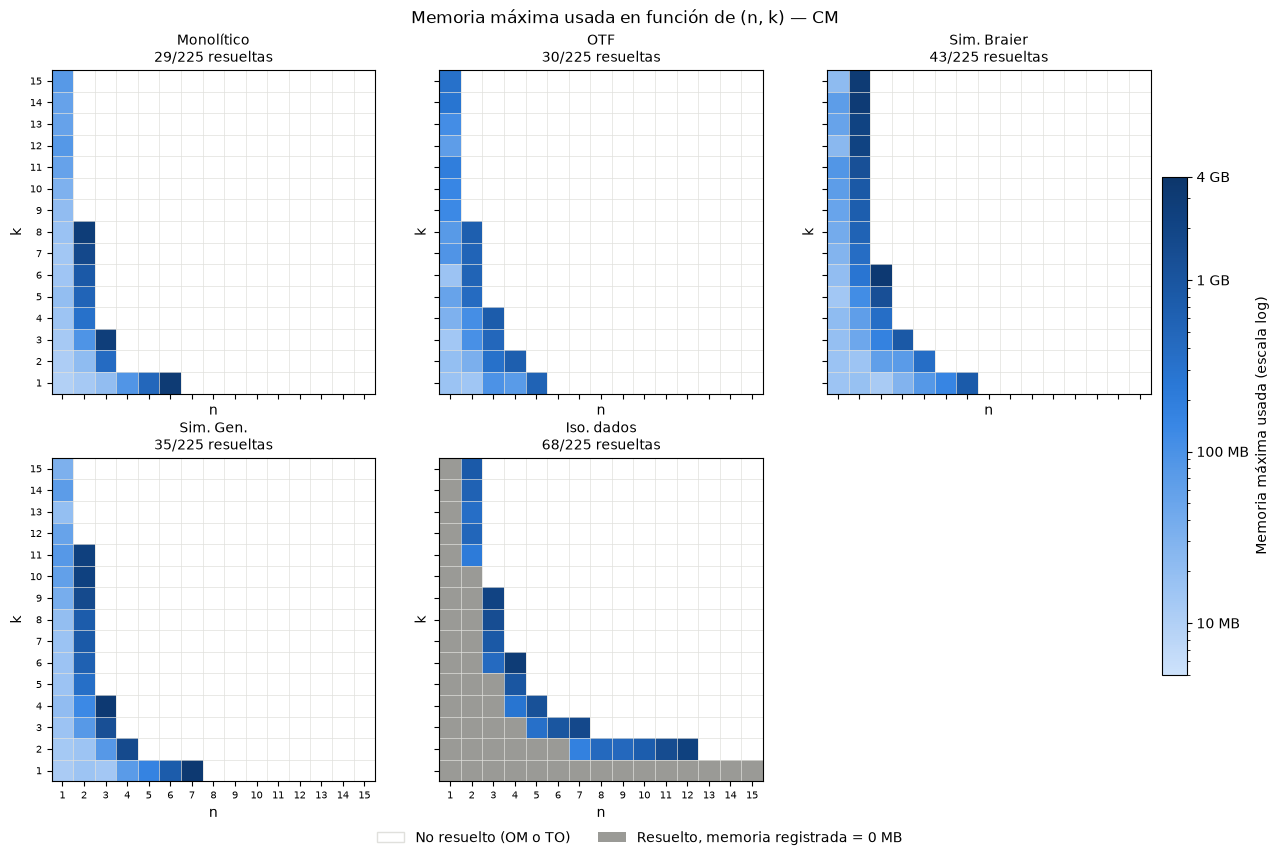

In [42]:
for problema in ["AT", "BW", "CM"]:
    plot_heatmap(problema, "memoria")